У цьому ДЗ ми потренуємось розв'язувати задачу багатокласової класифікації за допомогою логістичної регресії з використанням стратегій One-vs-Rest та One-vs-One, оцінити якість моделей та порівняти стратегії.

### Опис задачі і даних

**Контекст**

В цьому ДЗ ми працюємо з даними про сегментацію клієнтів.

Сегментація клієнтів – це практика поділу бази клієнтів на групи індивідів, які схожі між собою за певними критеріями, що мають значення для маркетингу, такими як вік, стать, інтереси та звички у витратах.

Компанії, які використовують сегментацію клієнтів, виходять з того, що кожен клієнт є унікальним і що їхні маркетингові зусилля будуть більш ефективними, якщо вони орієнтуватимуться на конкретні, менші групи зі зверненнями, які ці споживачі вважатимуть доречними та які спонукатимуть їх до купівлі. Компанії також сподіваються отримати глибше розуміння уподобань та потреб своїх клієнтів з метою виявлення того, що кожен сегмент цінує найбільше, щоб точніше адаптувати маркетингові матеріали до цього сегменту.

**Зміст**.

Автомобільна компанія планує вийти на нові ринки зі своїми існуючими продуктами (P1, P2, P3, P4 і P5). Після інтенсивного маркетингового дослідження вони дійшли висновку, що поведінка нового ринку схожа на їхній існуючий ринок.

На своєму існуючому ринку команда з продажу класифікувала всіх клієнтів на 4 сегменти (A, B, C, D). Потім вони здійснювали сегментовані звернення та комунікацію з різними сегментами клієнтів. Ця стратегія працювала для них надзвичайно добре. Вони планують використати ту саму стратегію на нових ринках і визначили 2627 нових потенційних клієнтів.

Ви маєте допомогти менеджеру передбачити правильну групу для нових клієнтів.

В цьому ДЗ використовуємо дані `customer_segmentation_train.csv`[скачати дані](https://drive.google.com/file/d/1VU1y2EwaHkVfr5RZ1U4MPWjeflAusK3w/view?usp=sharing). Це `train.csv`з цього [змагання](https://www.kaggle.com/datasets/abisheksudarshan/customer-segmentation/data?select=train.csv)

**Завдання 1.** Завантажте та підготуйте датасет до аналізу. Виконайте обробку пропущених значень та необхідне кодування категоріальних ознак. Розбийте на тренувальну і тестувальну вибірку, де в тесті 20%. Памʼятаємо, що весь препроцесинг ліпше все ж тренувати на тренувальній вибірці і на тестувальній лише використовувати вже натреновані трансформери.
Але в даному випадку оскільки значень в категоріях небагато, можна зробити обробку і на оригінальних даних, а потім розбити - це простіше. Можна також реалізувати процесинг і тренування моделі з пайплайнами. Обирайте як вам зручніше.

In [1]:
import pandas as pd
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTENC
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from ml_homework.classification import (
    build_ovr_logistic_pipeline,
    compare_multiclass_predictions,
    evaluate_multiclass_model,
)
from ml_homework.eda import get_columns_summary, get_target_column
from ml_homework.paths import RAW_DATA_DIR

In [2]:
data_path = RAW_DATA_DIR / "customer_segmentation/customer_segmentation_train.csv"

In [3]:
raw_df = pd.read_csv(data_path)

In [4]:
raw_df

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...,...
8063,464018,Male,No,22,No,NaN,0.0,Low,7.0,Cat_1,D
8064,464685,Male,No,35,No,Executive,3.0,Low,4.0,Cat_4,D
8065,465406,Female,No,33,Yes,Healthcare,1.0,Low,1.0,Cat_6,D
8066,467299,Female,No,27,Yes,Healthcare,1.0,Low,4.0,Cat_6,B


In [5]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   str    
 2   Ever_Married     7928 non-null   str    
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   str    
 5   Profession       7944 non-null   str    
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   str    
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   str    
 10  Segmentation     8068 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 918.9 KB


In [6]:
raw_df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [7]:
raw_df.isnull().sum()

ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64

In [8]:
X = raw_df.drop(columns=["Segmentation", "ID"])
y = raw_df["Segmentation"]

In [9]:
train_df, test_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=y)

In [10]:
print("train_df.shape:", train_df.shape)
print("test_df.shape:", test_df.shape)

print(
    "train percentage:", round(train_df.shape[0] / raw_df.shape[0] * 100, 2), end=" %\n"
)
print("test percentage:", round(test_df.shape[0] / raw_df.shape[0] * 100, 2), end=" %")

train_df.shape: (6454, 11)
test_df.shape: (1614, 11)
train percentage: 80.0 %
test percentage: 20.0 %

In [11]:
input_cols = X.columns.to_list()
target_col = y.name

In [12]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [13]:
test_inputs = test_df[input_cols].copy()
test_targets = test_df[target_col].copy()

In [14]:
ever_married_counts = train_inputs["Ever_Married"].value_counts()
ever_married_counts

Ever_Married
Yes    3734
No     2609
Name: count, dtype: int64

In [15]:
graduated_counts = train_inputs["Graduated"].value_counts()
graduated_counts

Graduated
Yes    4007
No     2388
Name: count, dtype: int64

In [16]:
gender_codes = get_target_column(train_inputs, "Gender")
gender_codes

{'Male': 1, 'Female': 0}

In [17]:
binary_codes = {"Yes": 1, "No": 0}

In [18]:
train_inputs["Ever_Married"] = train_inputs["Ever_Married"].map(binary_codes)
train_inputs["Graduated"] = train_inputs["Graduated"].map(binary_codes)
train_inputs["Gender"] = train_inputs["Gender"].map(gender_codes)
test_inputs["Ever_Married"] = test_inputs["Ever_Married"].map(binary_codes)
test_inputs["Graduated"] = test_inputs["Graduated"].map(binary_codes)
test_inputs["Gender"] = test_inputs["Gender"].map(gender_codes)

In [19]:
train_inputs

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
917,0,0.0,32,1.0,Artist,9.0,Low,1.0,Cat_6
3398,1,1.0,72,1.0,Entertainment,NaN,Average,2.0,Cat_6
2045,0,0.0,33,1.0,Entertainment,1.0,Low,4.0,Cat_6
8060,0,1.0,48,1.0,Artist,0.0,Average,6.0,Cat_6
4604,0,1.0,28,0.0,Doctor,9.0,Low,1.0,Cat_7
...,...,...,...,...,...,...,...,...,...
3822,0,0.0,27,0.0,Homemaker,8.0,Low,1.0,Cat_6
5864,1,0.0,37,1.0,Healthcare,0.0,Low,2.0,Cat_6
3589,0,0.0,27,0.0,Engineer,6.0,Low,6.0,Cat_4
1489,1,0.0,26,0.0,Artist,0.0,Low,2.0,Cat_6


In [20]:
categorical_train_df = train_inputs.select_dtypes(include=["object", "string"])

In [21]:
numeric_train_df = train_inputs.select_dtypes(include="number")

In [22]:
categorical_cols = categorical_train_df.columns.to_list()

In [23]:
numeric_columns_list = numeric_train_df.columns.to_list()
numeric_columns_list

['Gender',
 'Ever_Married',
 'Age',
 'Graduated',
 'Work_Experience',
 'Family_Size']

In [24]:
data_categorical_summary = get_columns_summary(categorical_cols, categorical_train_df)

data_categorical_summary

,column,nunique,unique_values
0,Profession,9,"[Artist, Entertainment, Doctor, Engineer, Heal..."
1,Spending_Score,3,"[Low, Average, High]"
2,Var_1,7,"[Cat_6, Cat_7, Cat_3, Cat_2, Cat_4, Cat_1, Cat_5]"


In [25]:
data_numeric_summary = get_columns_summary(numeric_columns_list, numeric_train_df)

data_numeric_summary

,column,nunique,unique_values
0,Gender,2,"[0, 1]"
1,Ever_Married,2,"[0.0, 1.0]"
2,Age,67,"[32, 72, 33, 48, 28, 45, 43, 38, 25, 35, 83, 4..."
3,Graduated,2,"[1.0, 0.0]"
4,Work_Experience,15,"[9.0, 1.0, 0.0, 3.0, 4.0, 7.0, 13.0, 8.0, 12.0..."
5,Family_Size,9,"[1.0, 2.0, 4.0, 6.0, 3.0, 5.0, 9.0, 7.0, 8.0]"


In [26]:
train_inputs[numeric_columns_list].describe().round(2)

,Gender,Ever_Married,Age,Graduated,Work_Experience,Family_Size
count,6454.00,6343.00,6454.00,6395.00,5808.00,6190.00
mean,0.54,0.59,43.59,0.63,2.67,2.84
std,0.50,0.49,16.67,0.48,3.43,1.53
min,0.00,0.00,18.00,0.00,0.00,1.00
25%,0.00,0.00,31.00,0.00,0.00,2.00
50%,1.00,1.00,41.00,1.00,1.00,3.00
75%,1.00,1.00,53.00,1.00,4.00,4.00
max,1.00,1.00,89.00,1.00,14.00,9.00


In [27]:
train_inputs[numeric_columns_list].isna().sum()

Gender               0
Ever_Married       111
Age                  0
Graduated           59
Work_Experience    646
Family_Size        264
dtype: int64

In [28]:
train_inputs[categorical_cols].isna().sum()

Profession        106
Spending_Score      0
Var_1              60
dtype: int64

In [29]:
binary_columns = [
    "Gender",
    "Ever_Married",
    "Graduated",
]

numeric_cols = numeric_train_df.columns.difference(binary_columns).tolist()

In [30]:
numeric_cols, categorical_cols

(['Age', 'Family_Size', 'Work_Experience'],
 ['Profession', 'Spending_Score', 'Var_1'])

In [31]:
binary_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
    ]
)
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
            ),
        ),
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing",
            ),
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore"),
        ),
    ]
)

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ("binary", binary_transformer, binary_columns),
        ("numeric", numeric_transformer, numeric_cols),
        ("categorical", categorical_transformer, categorical_cols),
    ]
)

In [33]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                solver="lbfgs",
                max_iter=1_000,
                random_state=42,
            ),
        ),
    ]
)

In [34]:
model_pipeline.fit(train_inputs, train_targets)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](4,)","['A','B','C','D']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Gender','Ever_Married','Age',...,'Spending_Score','Family_Size','Var_1']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('binary', ...), ('numeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``

Training Accuracy: 0.5178
Training Macro F1: 0.4951
Training Macro AUROC: 0.7679

Training Confusion Matrix — кількість:
          Predicted A  Predicted B  Predicted C  Predicted D
Actual A          755          242          271          310
Actual B          438          343          516          189
Actual C          196          224          942          214
Actual D          353           82           77         1302

Training Confusion Matrix — частка:
          Predicted A  Predicted B  Predicted C  Predicted D
Actual A        0.478        0.153        0.172        0.196
Actual B        0.295        0.231        0.347        0.127
Actual C        0.124        0.142        0.598        0.136
Actual D        0.195        0.045        0.042        0.718
Validation Accuracy: 0.5130
Validation Macro F1: 0.4906
Validation Macro AUROC: 0.7732

Validation Confusion Matrix — кількість:
          Predicted A  Predicted B  Predicted C  Predicted D
Actual A          165           65        

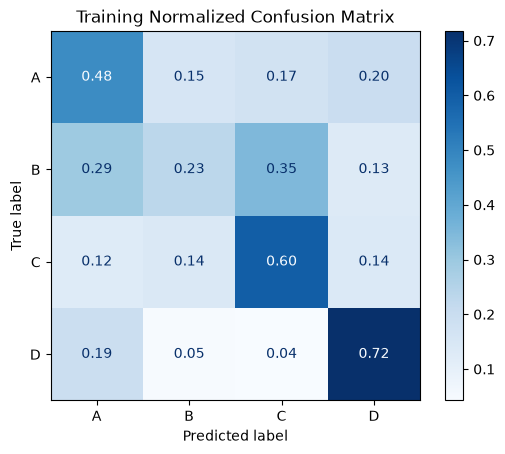

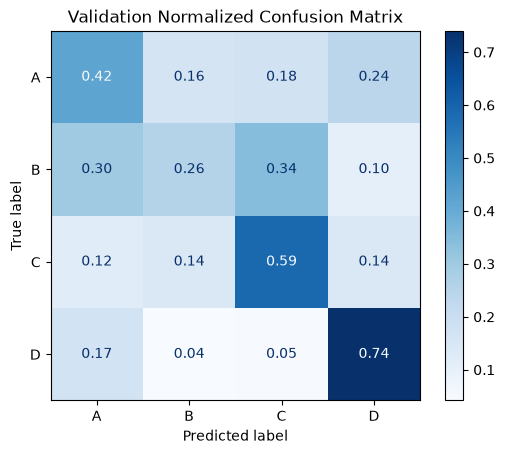

In [35]:
train_preds = evaluate_multiclass_model(
    model_pipeline,
    train_inputs,
    train_targets,
    "Training",
)

val_preds = evaluate_multiclass_model(
    model_pipeline,
    test_inputs,
    test_targets,
    "Validation",
)

In [36]:
raw_df["Segmentation"].value_counts(normalize=True).mul(100).round(4)

Segmentation
D    28.1111
A    24.4422
C    24.4175
B    23.0293
Name: proportion, dtype: float64

**Завдання 2. Важливо уважно прочитати все формулювання цього завдання до кінця!**

Застосуйте методи ресемплингу даних SMOTE та SMOTE-Tomek з бібліотеки imbalanced-learn до тренувальної вибірки. В результаті у Вас має вийти 2 тренувальних набори: з апсемплингом зі SMOTE, та з ресамплингом з SMOTE-Tomek.

Увага! В нашому наборі даних є як категоріальні дані, так і звичайні числові. Базовий SMOTE не буде правильно працювати з категоріальними даними, але є його модифікація, яка буде. Тому в цього завдання є 2 виконання

  1. Застосувати SMOTE базовий лише на НЕкатегоріальних ознаках.

  2. Переглянути інформацію про метод [SMOTENC](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTENC.html#imblearn.over_sampling.SMOTENC) і використати цей метод в цій задачі. За цей спосіб буде +3 бали за це завдання і він рекомендований для виконання.

  **Підказка**: аби скористатись SMOTENC треба створити змінну, яка містить індекси ознак, які є категоріальними (їх номер серед колонок) і передати при ініціації екземпляра класу `SMOTENC(..., categorical_features=cat_feature_indeces)`.
  
  Ви також можете розглянути варіант використання варіації SMOTE, який працює ЛИШЕ з категоріальними ознаками [SMOTEN](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTEN.html)

In [37]:
smote_imputer = ColumnTransformer(
    transformers=[
        (
            "binary",
            SimpleImputer(strategy="most_frequent"),
            binary_columns,
        ),
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_cols,
        ),
        (
            "categorical",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing",
            ),
            categorical_cols,
        ),
    ],
    verbose_feature_names_out=False,
).set_output(transform="pandas")

In [38]:
train_inputs_imputed = smote_imputer.fit_transform(train_inputs)

test_inputs_imputed = smote_imputer.transform(test_inputs)

In [39]:
train_inputs_imputed.isna().sum()

Gender             0
Ever_Married       0
Graduated          0
Age                0
Family_Size        0
Work_Experience    0
Profession         0
Spending_Score     0
Var_1              0
dtype: int64

In [40]:
categorical_columns_for_smote = binary_columns + categorical_cols

categorical_features = [
    train_inputs_imputed.columns.get_loc(column)
    for column in categorical_columns_for_smote
]

categorical_features

[0, 1, 2, 6, 7, 8]

In [41]:
smotenc = SMOTENC(
    categorical_features=categorical_features,
    random_state=42,
)

X_train_smotenc, y_train_smotenc = smotenc.fit_resample(
    train_inputs_imputed,
    train_targets,
)

In [42]:
print("До SMOTENC:")
print(train_targets.value_counts())

print("\nПісля SMOTENC:")
print(y_train_smotenc.value_counts())

До SMOTENC:
Segmentation
D    1814
A    1578
C    1576
B    1486
Name: count, dtype: int64

Після SMOTENC:
Segmentation
A    1814
B    1814
C    1814
D    1814
Name: count, dtype: int64


In [43]:
fitted_preprocessor = model_pipeline.named_steps["preprocessor"]

X_train_transformed = fitted_preprocessor.transform(train_inputs)

X_test_transformed = fitted_preprocessor.transform(test_inputs)

In [44]:
smotetomek = SMOTETomek(random_state=42)
X_train_smotetomek, y_train_smotetomek = smotetomek.fit_resample(
    X_train_transformed, train_targets
)

In [45]:
print("До SMOTE-Tomek:")
print(train_targets.value_counts())

print("\nПісля SMOTE-Tomek:")
print(y_train_smotetomek.value_counts())

До SMOTE-Tomek:
Segmentation
D    1814
A    1578
C    1576
B    1486
Name: count, dtype: int64

Після SMOTE-Tomek:
Segmentation
D    1499
C    1482
A    1437
B    1430
Name: count, dtype: int64


**Завдання 3**.
  1. Навчіть модель логістичної регресії з використанням стратегії One-vs-Rest з логістичною регресією на оригінальних даних, збалансованих з SMOTE, збалансованих з Smote-Tomek.  
  2. Виміряйте якість кожної з натренованих моделей використовуючи `sklearn.metrics.classification_report`.
  3. Напишіть, яку метрику ви обрали для порівняння моделей.
  4. Яка модель найкраща?
  5. Якщо немає суттєвої різниці між моделями - напишіть свою гіпотезу, чому?

In [46]:
ovr_original_model = build_ovr_logistic_pipeline(preprocessor)
ovr_original_model.fit(train_inputs, train_targets)
ovr_original_predictions = ovr_original_model.predict(test_inputs)

print("Original data:")
print(
    classification_report(
        test_targets,
        ovr_original_predictions,
        digits=4,
        zero_division=0,
    )
)

Original data:
              precision    recall  f1-score   support

           A     0.4269    0.4594    0.4425       394
           B     0.3865    0.1694    0.2355       372
           C     0.4909    0.6193    0.5477       394
           D     0.6547    0.7643    0.7053       454

    accuracy                         0.5173      1614
   macro avg     0.4898    0.5031    0.4828      1614
weighted avg     0.4973    0.5173    0.4944      1614



In [47]:
ovr_smotenc_model = build_ovr_logistic_pipeline(preprocessor)
ovr_smotenc_model.fit(X_train_smotenc, y_train_smotenc)
ovr_smotenc_predictions = ovr_smotenc_model.predict(test_inputs_imputed)

print("SMOTENC data:")
print(
    classification_report(
        test_targets,
        ovr_smotenc_predictions,
        digits=4,
        zero_division=0,
    )
)

SMOTENC data:
              precision    recall  f1-score   support

           A     0.4250    0.4746    0.4484       394
           B     0.3974    0.2446    0.3028       372
           C     0.5066    0.5863    0.5435       394
           D     0.6728    0.7247    0.6978       454

    accuracy                         0.5192      1614
   macro avg     0.5004    0.5076    0.4981      1614
weighted avg     0.5083    0.5192    0.5082      1614



In [48]:
ovr_smotetomek_model = build_ovr_logistic_pipeline()
ovr_smotetomek_model.fit(X_train_smotetomek, y_train_smotetomek)
ovr_smotetomek_predictions = ovr_smotetomek_model.predict(X_test_transformed)

print("SMOTE-Tomek data:")
print(
    classification_report(
        test_targets,
        ovr_smotetomek_predictions,
        digits=4,
        zero_division=0,
    )
)

SMOTE-Tomek data:
              precision    recall  f1-score   support

           A     0.4201    0.4873    0.4512       394
           B     0.3857    0.2312    0.2891       372
           C     0.5065    0.5939    0.5467       394
           D     0.6780    0.7048    0.6911       454

    accuracy                         0.5155      1614
   macro avg     0.4976    0.5043    0.4945      1614
weighted avg     0.5058    0.5155    0.5047      1614



In [49]:
metrics_comparison = compare_multiclass_predictions(
    {
        "Original": ovr_original_predictions,
        "SMOTENC": ovr_smotenc_predictions,
        "SMOTE-Tomek": ovr_smotetomek_predictions,
    },
    test_targets,
)
metrics_comparison.round(4)

,Original,SMOTENC,SMOTE-Tomek
Accuracy,0.5173,0.5192,0.5155
Macro Precision,0.4898,0.5004,0.4976
Macro Recall,0.5031,0.5076,0.5043
Macro F1,0.4828,0.4981,0.4945


Для порівняння моделей я обрала Macro F1-score, оскільки ця метрика одночасно враховує precision і recall та надає однакову вагу кожному класу. Найкращий результат показала модель, навчена на даних після SMOTENC: її Macro F1 становить 0.4981 проти 0.4828 у моделі на початкових даних. Найбільше покращилася якість визначення класу B: F1 зріс із 0.2355 до 0.3028. Водночас різниця між моделями невелика, оскільки початковий датасет не має сильної незбалансованості класів.